# COVID-19 Early Case Trend Analysis & Recovery Insights

## Machine Learning Minor Project

**Company:** HealthGuard Analytics Pvt. Ltd.

**Student:** Nikhil Kumar Sharma

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn`

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## 1. Import Required Libraries

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [28]:
df = pd.read_csv("../data/dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## 3. Display First 5 Records

In [29]:
df.head()


,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


## 4. Dataset Shape

In [30]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4212
Columns: 14


## 5. Column Names

In [31]:
df.columns.tolist()

['id',
 'sex',
 'birth_year',
 'country',
 'region',
 'group',
 'infection_reason',
 'infection_order',
 'infected_by',
 'contact_number',
 'confirmed_date',
 'released_date',
 'deceased_date',
 'state']

# 6. Data Cleaning & Feature Engineering

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    str    
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   str    
 4   region            305 non-null    str    
 5   group             76 non-null     str    
 6   infection_reason  130 non-null    str    
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   str    
 11  released_date     28 non-null     str    
 12  deceased_date     13 non-null     str    
 13  state             4212 non-null   str    
dtypes: float64(4), int64(1), str(9)
memory usage: 460.8 KB


## 6.2 Missing Values

In [25]:
df.isnull().sum()

id                     0
sex                 3894
birth_year          3920
country                0
region              3907
group               4136
infection_reason    4082
infection_order     4177
infected_by         4150
contact_number      4180
confirmed_date         0
released_date       4184
deceased_date       4199
state                  0
dtype: int64

## 6.3 Duplicate Records

In [32]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 6.4 Remove Duplicate Records

In [33]:
df = df.drop_duplicates()

print(df.shape)

(4212, 14)


## 6.5 Convert Date Columns

In [35]:
date_columns = [
    "confirmed_date",
    "released_date",
    "deceased_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

## 6.6 Verify Date Conversion

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                4212 non-null   int64         
 1   sex               318 non-null    str           
 2   birth_year        292 non-null    float64       
 3   country           4212 non-null   str           
 4   region            305 non-null    str           
 5   group             76 non-null     str           
 6   infection_reason  130 non-null    str           
 7   infection_order   35 non-null     float64       
 8   infected_by       62 non-null     float64       
 9   contact_number    32 non-null     float64       
 10  confirmed_date    4212 non-null   datetime64[us]
 11  released_date     28 non-null     datetime64[us]
 12  deceased_date     13 non-null     datetime64[us]
 13  state             4212 non-null   str           
dtypes: datetime64[us](3), float64(4), i

## 6.7 Create Age Column

In [37]:
CURRENT_YEAR = 2020

df["Age"] = CURRENT_YEAR - df["birth_year"]

## 6.8 Create Recovery Days

In [38]:
df["Recovery_Days"] = (
    df["released_date"] -
    df["confirmed_date"]
).dt.days

## 6.9 Save Clean Dataset

In [39]:
df.to_csv("../data/cleaned_dataset.csv", index=False)

# 7. Exploratory Data Analysis (EDA)

## 7.1 Gender Distribution

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25020\3564863879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


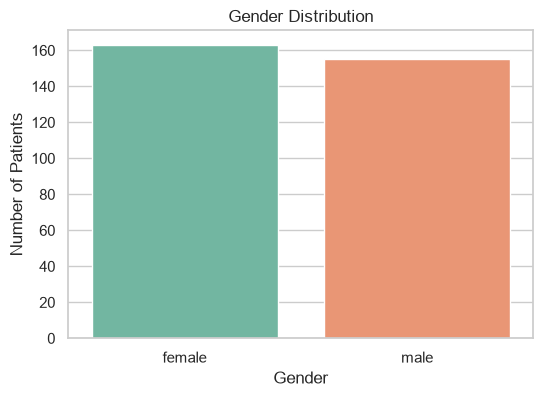

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sex",
    palette="Set2"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

## 7.2 Age Distribution

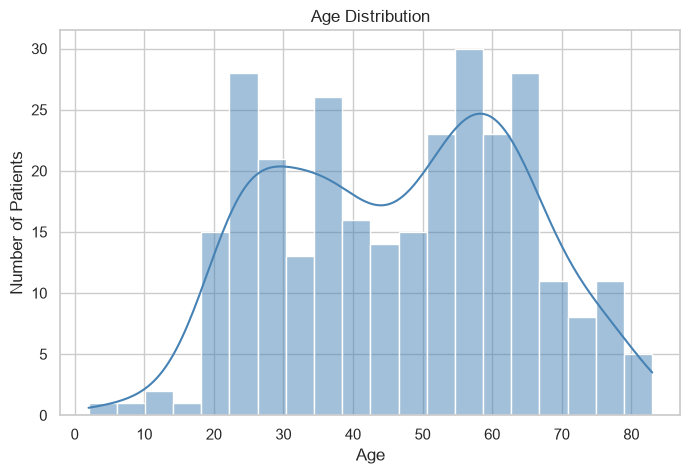

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

## 7.3 Country Distribution

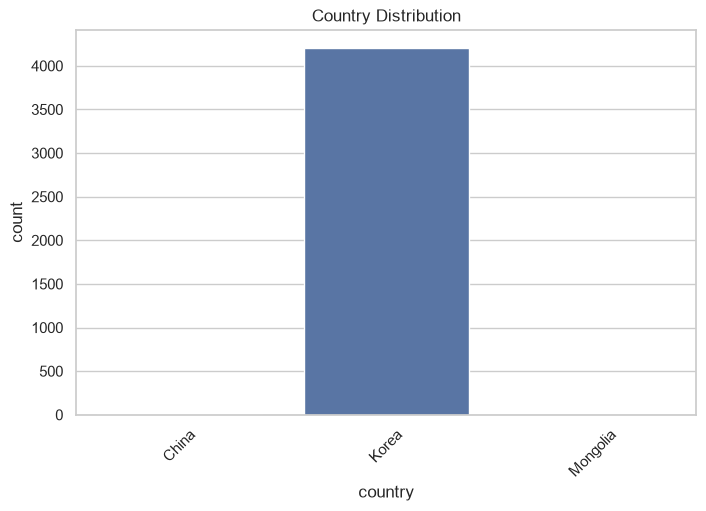

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="country"
)

plt.title("Country Distribution")
plt.xticks(rotation=45)

plt.show()

## 7.4 Top 10 Most Affected Regions

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25020\2119036125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


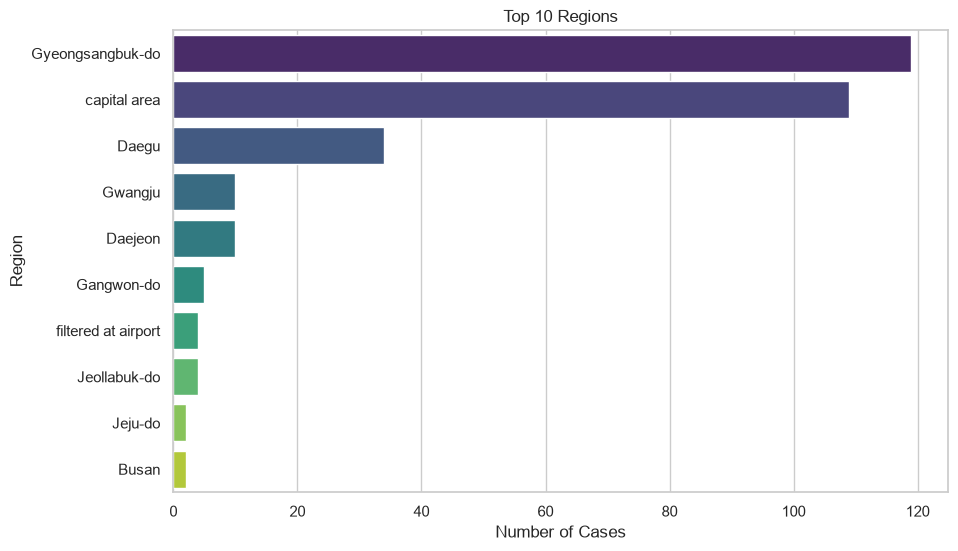

In [43]:
top_regions = df["region"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_regions.values,
    y=top_regions.index,
    palette="viridis"
)

plt.title("Top 10 Regions")
plt.xlabel("Number of Cases")
plt.ylabel("Region")

plt.show()

## 7.5 Patient State

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25020\2369931577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


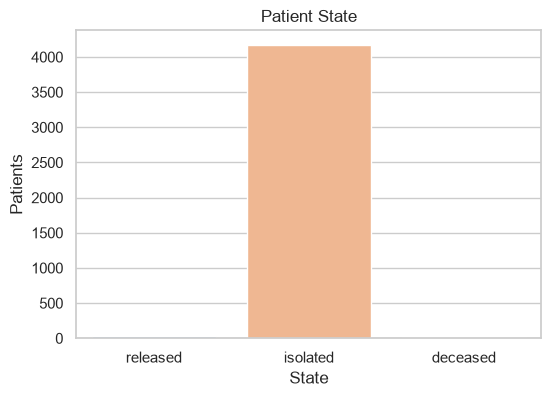

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="state",
    palette="pastel"
)

plt.title("Patient State")
plt.xlabel("State")
plt.ylabel("Patients")

plt.show()

## 7.6 Infection Reason

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25020\4087857508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


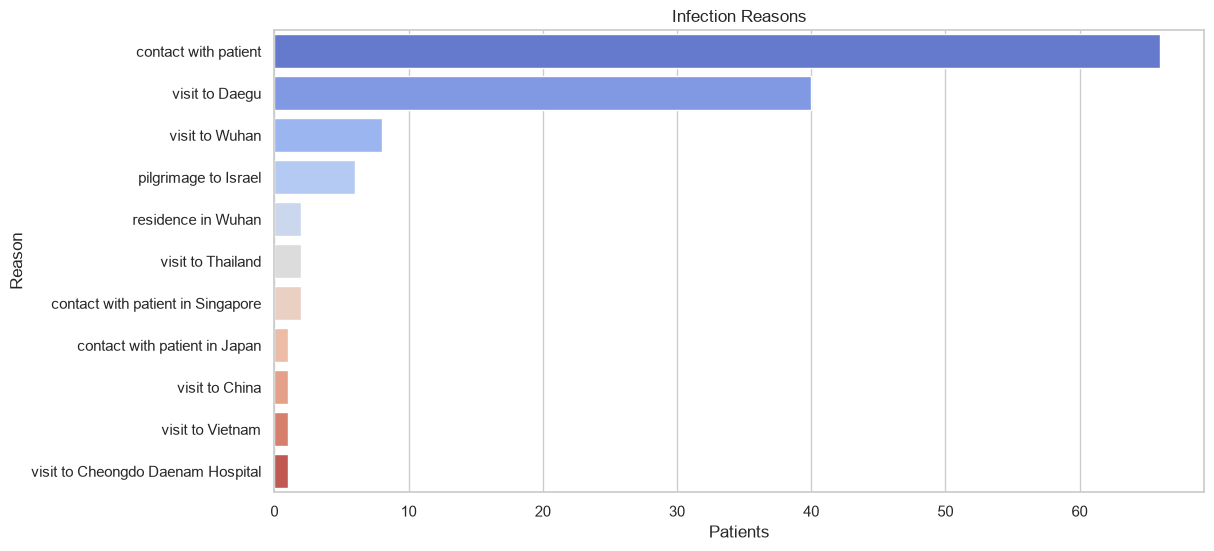

In [45]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="infection_reason",
    order=df["infection_reason"].value_counts().index,
    palette="coolwarm"
)

plt.title("Infection Reasons")
plt.xlabel("Patients")
plt.ylabel("Reason")

plt.show()

## 7.7 Infection Order

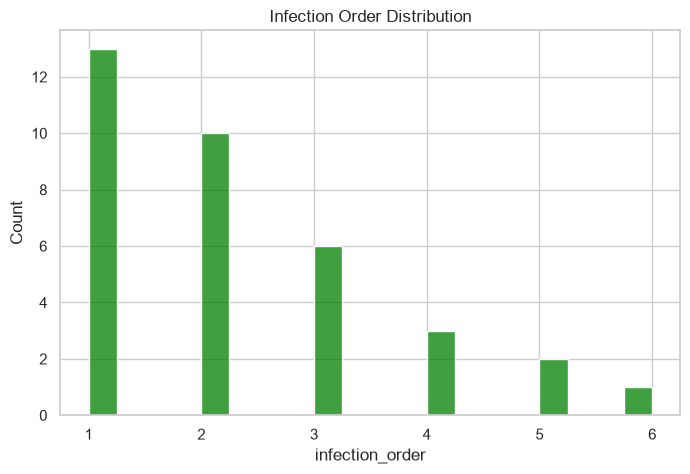

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="infection_order",
    bins=20,
    color="green"
)

plt.title("Infection Order Distribution")

plt.show()

## 7.8 Contact Number Distribution

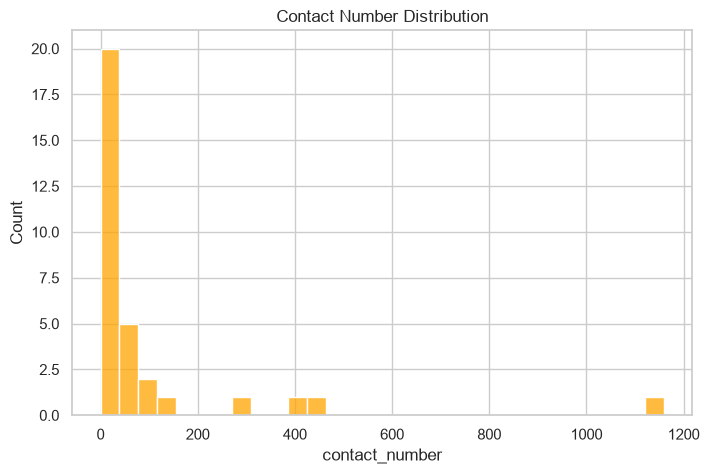

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="contact_number",
    bins=30,
    color="orange"
)

plt.title("Contact Number Distribution")

plt.show()

## 7.9 Recovery Days Distribution

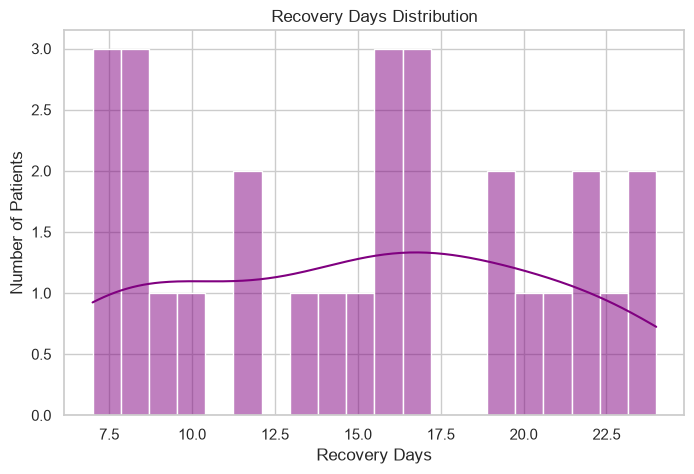

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Recovery_Days",
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Recovery Days Distribution")
plt.xlabel("Recovery Days")
plt.ylabel("Number of Patients")

plt.show()

## 7.10 Recovery Days by Gender

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25020\2356688996.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


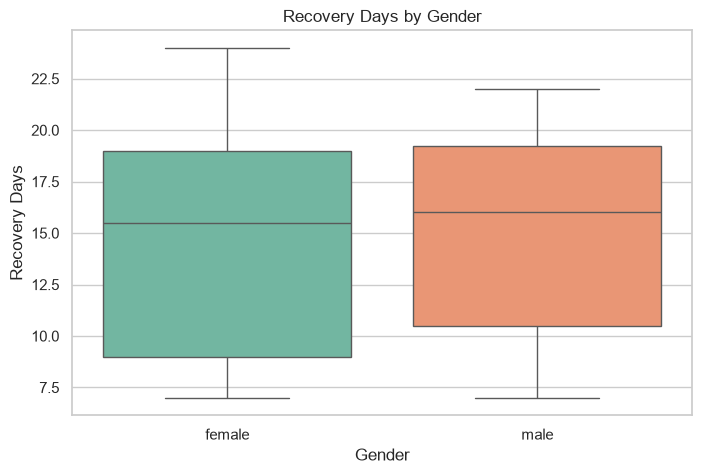

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sex",
    y="Recovery_Days",
    palette="Set2"
)

plt.title("Recovery Days by Gender")
plt.xlabel("Gender")
plt.ylabel("Recovery Days")

plt.show()

## 7.11 Age vs Recovery Days

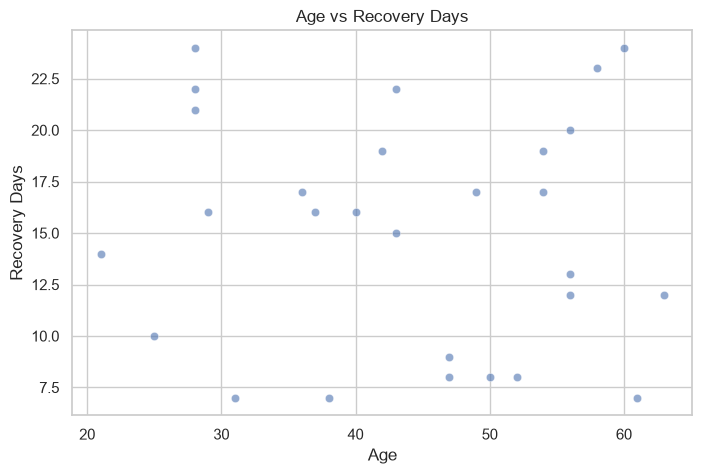

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Recovery_Days",
    alpha=0.6
)

plt.title("Age vs Recovery Days")
plt.xlabel("Age")
plt.ylabel("Recovery Days")

plt.show()

## 7.12 Infection Order vs Recovery Days

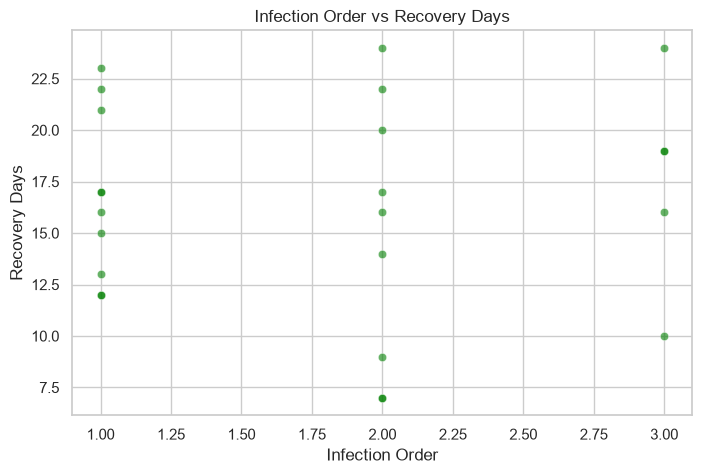

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="infection_order",
    y="Recovery_Days",
    alpha=0.6,
    color="green"
)

plt.title("Infection Order vs Recovery Days")
plt.xlabel("Infection Order")
plt.ylabel("Recovery Days")

plt.show()

## 7.13 Correlation Heatmap

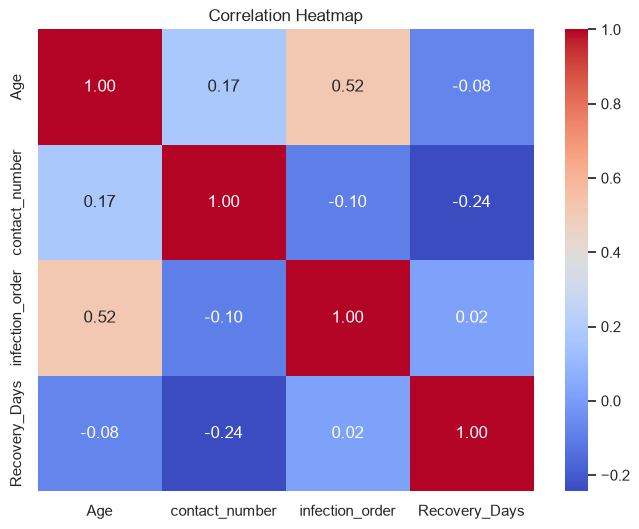

In [52]:
correlation = df[
    ["Age", "contact_number", "infection_order", "Recovery_Days"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 7.14 Pair Plot

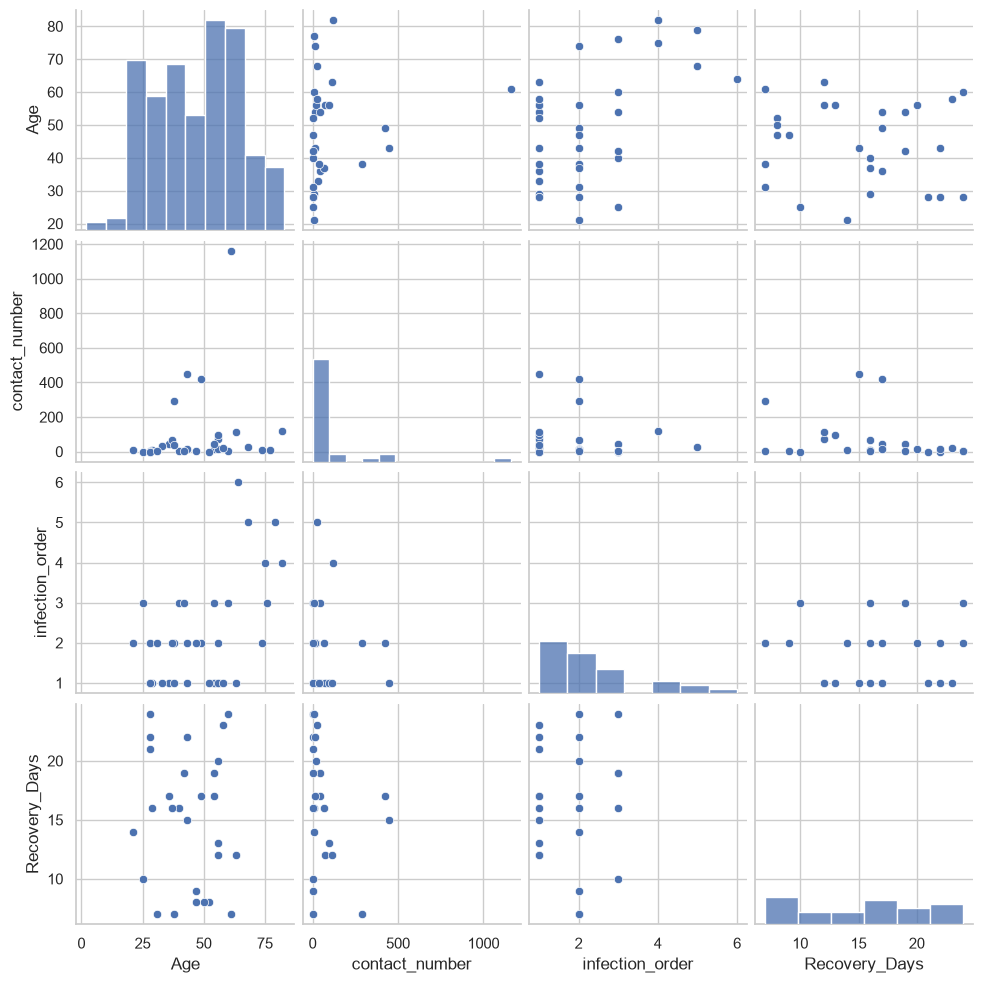

In [53]:
sns.pairplot(
    df[
        ["Age", "contact_number", "infection_order", "Recovery_Days"]
    ]
)

plt.show()

## 7.15 Patient Outcome Distribution

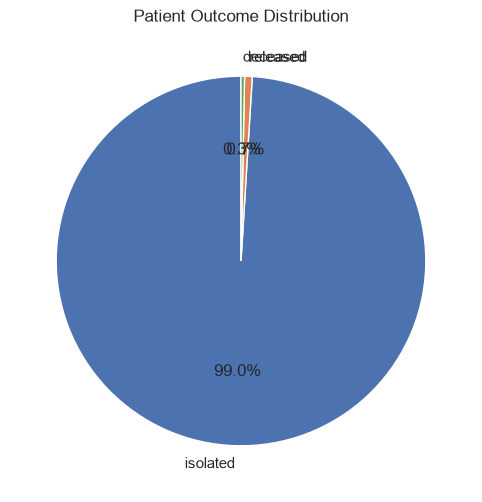

In [54]:
state_counts = df["state"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    state_counts,
    labels=state_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Patient Outcome Distribution")

plt.show()

# 8. Linear Regression Model

## 8.1 Feature Selection

In [55]:
# Select Features
X = df[["Age", "contact_number", "infection_order"]]

# Target Variable
y = df["Recovery_Days"]

## 8.2 Handle Missing Values

In [56]:
model_data = df[
    ["Age", "contact_number", "infection_order", "Recovery_Days"]
].dropna()

X = model_data[
    ["Age", "contact_number", "infection_order"]
]

y = model_data["Recovery_Days"]

print(model_data.shape)

(24, 4)


## 8.3 Train-Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (19, 3)
Testing Data  : (5, 3)


## 8.4 Create Linear Regression Model

In [58]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## 8.5 Prediction

In [59]:
y_pred = model.predict(X_test)

## 8.6 Actual vs Predicted Values

In [60]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
9,19.0,17.017407
17,14.0,14.718245
0,17.0,15.538658
19,19.0,16.448802
12,22.0,15.321882


## 8.7 Model Evaluation

In [61]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 2.6782992883968704
Mean Squared Error : 11.537589349357884
Root Mean Squared Error : 3.3967027172476962
R2 Score : -0.6576996191606157


## 8.8 Model Coefficients

In [62]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Age,0.078771
1,contact_number,-0.009186
2,infection_order,0.021251


## 8.9 Actual vs Predicted Plot

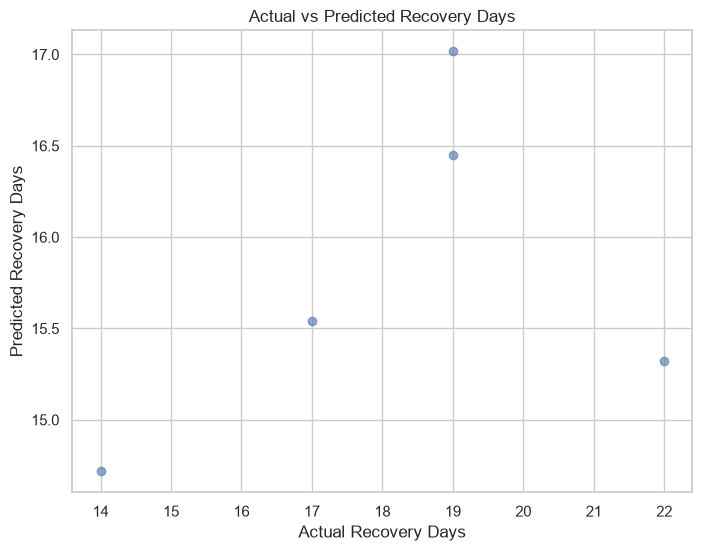

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Recovery Days")
plt.ylabel("Predicted Recovery Days")

plt.title("Actual vs Predicted Recovery Days")

plt.show()

## 8.10 Save Prediction Results

In [64]:
comparison.to_csv(
    "../outputs/predictions.csv",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


# 9. Results & Insights

## 9.1 Who is Getting Infected?

In [ ]:
print("Gender Distribution")
print(df["sex"].value_counts())

print("\nAverage Age")
print(df["Age"].mean())

print("\nCountry Distribution")
print(df["country"].value_counts())

print("\nTop 10 Regions")
print(df["region"].value_counts().head(10))

## 9.2 Infection Spread Analysis

In [ ]:
print("Infection Reasons")
print(df["infection_reason"].value_counts())

print("\nAverage Infection Order")
print(df["infection_order"].mean())

print("\nAverage Contact Number")
print(df["contact_number"].mean())

## 9.3 Recovery Trends

In [ ]:
print("Average Recovery Days")
print(df["Recovery_Days"].mean())

print("\nMedian Recovery Days")
print(df["Recovery_Days"].median())

print("\nMaximum Recovery Days")
print(df["Recovery_Days"].max())

print("\nMinimum Recovery Days")
print(df["Recovery_Days"].min())

## 9.4 Patient Outcomes

In [ ]:
print(df["state"].value_counts())

## 9.5 Correlation Analysis

In [ ]:
correlation = df[
    ["Age", "contact_number", "infection_order", "Recovery_Days"]
].corr()

correlation

## 9.5 Correlation Analysis

In [ ]:
correlation = df[
    ["Age", "contact_number", "infection_order", "Recovery_Days"]
].corr()

correlation

# 10. Conclusion

### Conclusion

The analysis of the COVID-19 patient dataset provided valuable insights into patient demographics, infection patterns, regional distribution, and recovery trends.

Exploratory Data Analysis identified differences in infection across age groups, gender, and regions. Recovery duration was calculated from confirmation and release dates, allowing further analysis of recovery behavior.

A Linear Regression model was developed to predict recovery days using Age, Contact Number, and Infection Order. The model demonstrated how machine learning can assist in understanding factors that influence recovery time.

Overall, this project illustrates how data analytics and machine learning can support public health authorities in making informed decisions during infectious disease outbreaks.

# 11. Future Scope

- Apply advanced machine learning algorithms such as Random Forest and XGBoost.
- Develop an interactive dashboard using Streamlit or Power BI.
- Include real-time COVID-19 datasets.
- Improve prediction accuracy using additional clinical features.
- Deploy the model as a web application for healthcare professionals.

# 12. References

1. Pandas Documentation - https://pandas.pydata.org/

2. NumPy Documentation - https://numpy.org/

3. Matplotlib Documentation - https://matplotlib.org/

4. Seaborn Documentation - https://seaborn.pydata.org/

5. Scikit-Learn Documentation - https://scikit-learn.org/

# 13. Export Final Dataset

In [ ]:
df.to_csv("../outputs/final_dataset.csv", index=False)

print("Final Dataset Saved Successfully!")